In [1]:
import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
from torchvision import models
from torchvision.models import MobileNet_V3_Small_Weights
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"MPS  available:  {torch.backends.mps.is_available()}")


PyTorch version: 2.11.0+cu130
CUDA available:  True
MPS  available:  False


Исходное число строк: 1,451,784
После фильтра quality: 1,431,975
Найдено jpg файлов: 61,827
После mapping: 61,827
Число классов до очистки: 23
[WARNING] Удалено 2 классов с количеством образцов < 5

Итоговое число классов: 21
Итоговое число строк: 61,825


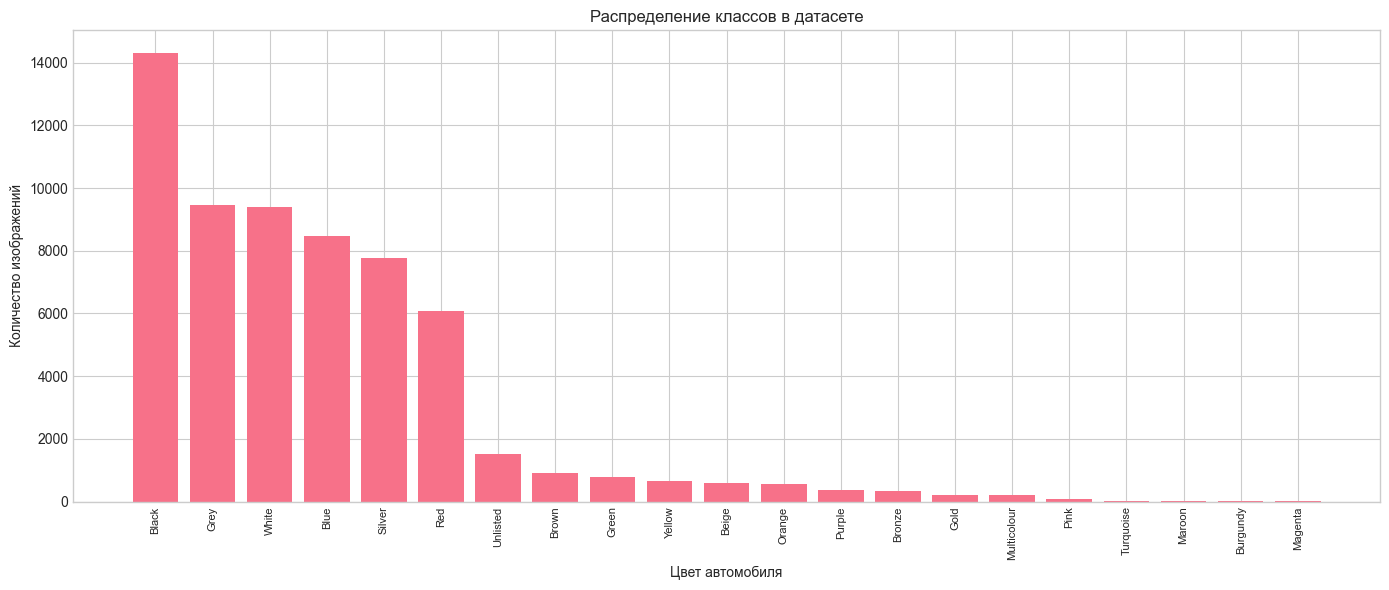

In [2]:
IMAGE_TABLE_PATH = Path('data/car_colors/1/Image_table.csv')
IMAGES_DIR = Path('data/car_colors/1/confirmed_fronts')

image_df = pd.read_csv(str(IMAGE_TABLE_PATH))
image_df.columns = [c.strip() for c in image_df.columns]
print(f'Исходное число строк: {len(image_df):,}')

def parse_image_name(name):
    parts = str(name).split('$$')
    if len(parts) >= 4:
        return {
            'color': parts[3].strip(),
            'quality': parts[4].strip() if len(parts) > 4 else '',
            'angle': parts[5].strip() if len(parts) > 5 else ''
        }
    return {'color': ''}

parsed = image_df['Image_name'].apply(parse_image_name)
image_df['parsed_color'] = parsed.apply(lambda x: x['color'])
image_df['parsed_quality'] = parsed.apply(lambda x: x['quality'])
image_df['parsed_angle'] = parsed.apply(lambda x: x['angle'])


USE_QUALITY_ONLY = True
if USE_QUALITY_ONLY and 'Quality_check' in image_df.columns:
    image_df = image_df[image_df['Quality_check'].fillna('').astype(str).str.strip().ne('N')].copy()
print(f'После фильтра quality: {len(image_df):,}')


all_image_paths = list(IMAGES_DIR.rglob('*.jpg'))
image_name_to_path = {path.name: path for path in all_image_paths}
print(f'Найдено jpg файлов: {len(all_image_paths):,}')

image_df['image_path'] = image_df['Image_name'].map(image_name_to_path)
image_df = image_df.dropna(subset=['image_path']).copy()
print(f'После mapping: {len(image_df):,}')


color_to_idx = {color: idx for idx, color in enumerate(sorted(image_df['parsed_color'].unique()))}
idx_to_color = {idx: color for color, idx in color_to_idx.items()}
image_df['label'] = image_df['parsed_color'].map(color_to_idx)
num_classes_initial = len(color_to_idx)
print(f'Число классов до очистки: {num_classes_initial}')


class_counts = image_df['label'].value_counts()
MIN_SAMPLES_PER_CLASS = 5
valid_labels = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index

if len(valid_labels) < len(class_counts):
    removed_count = len(class_counts) - len(valid_labels)
    print(f'[WARNING] Удалено {removed_count} классов с количеством образцов < {MIN_SAMPLES_PER_CLASS}')

image_df = image_df[image_df['label'].isin(valid_labels)].reset_index(drop=True)


unique_colors = sorted(image_df['parsed_color'].unique())
color_to_idx = {color: idx for idx, color in enumerate(unique_colors)}
idx_to_color = {idx: color for color, idx in color_to_idx.items()}
image_df['label'] = image_df['parsed_color'].map(color_to_idx)
num_classes = len(color_to_idx)

print(f'\n{"="*50}')
print(f'Итоговое число классов: {num_classes}')
print(f'Итоговое число строк: {len(image_df):,}')
print(f'{"="*50}')


plt.figure(figsize=(14, 6))
class_distribution = image_df['parsed_color'].value_counts()
plt.bar(range(len(class_distribution)), class_distribution.values)
plt.xticks(range(len(class_distribution)), class_distribution.index, rotation=90, fontsize=8)
plt.xlabel('Цвет автомобиля')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в датасете')
plt.tight_layout()
plt.show()

In [ ]:

train_df, val_df = train_test_split(
    image_df,
    test_size=0.2,
    random_state=42,
    stratify=image_df['label']
)

print(f'Train size: {len(train_df):,} ({len(train_df)/len(image_df)*100:.1f}%)')
print(f'Val size: {len(val_df):,} ({len(val_df)/len(image_df)*100:.1f}%)')


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CarColorDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = row['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = CarColorDataset(train_df, transform=train_transforms)
val_dataset = CarColorDataset(val_df, transform=val_transforms)

_pin = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=_pin)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=_pin)

print(f"\nBatch size: 32")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train size: 49,460 (80.0%)
Val size: 12,365 (20.0%)

Batch size: 32
Train batches: 1546
Val batches: 387


In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Validating', leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_labels

def train_model(model, model_name, train_loader, val_loader, num_classes, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1 = 0
    best_model_state = None

    print(f"\n{'='*60}")
    print(f"Обучение модели: {model_name}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _ = validate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = model.state_dict().copy()

    print(f"\nЛучший F1 Macro: {best_f1:.4f}")
    print(f"{'='*60}\n")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history, best_f1

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['train_f1'], label='Train F1', marker='o')
    axes[1].plot(history['val_f1'], label='Val F1', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Macro')
    axes[1].set_title(f'{model_name} - F1 Macro')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(all_labels, all_preds, model_name, class_names=None):
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

Device: cuda



МОДЕЛЬ 1: ResNet50 (Pretrained на ImageNet)
Обучаемых параметров: 15,007,765 / 23,551,061 (63.7%)
Batch size: 32
Device: cuda

[Начало обучения...]
  Batch 50/1546 | Loss: 1.6672
  Batch 100/1546 | Loss: 1.0221
  Batch 150/1546 | Loss: 0.7907
  Batch 200/1546 | Loss: 0.7778
  Batch 250/1546 | Loss: 1.0890
  Batch 300/1546 | Loss: 0.8747
  Batch 350/1546 | Loss: 0.8998
  Batch 400/1546 | Loss: 0.5680
  Batch 450/1546 | Loss: 0.8254
  Batch 500/1546 | Loss: 0.6309
  Batch 550/1546 | Loss: 0.7789
  Batch 600/1546 | Loss: 0.7267
  Batch 650/1546 | Loss: 0.7646
  Batch 700/1546 | Loss: 0.7543
  Batch 750/1546 | Loss: 0.6541
  Batch 800/1546 | Loss: 0.6021
  Batch 850/1546 | Loss: 0.9153
  Batch 900/1546 | Loss: 0.3775
  Batch 950/1546 | Loss: 0.5861
  Batch 1000/1546 | Loss: 0.6662
  Batch 1050/1546 | Loss: 0.6549
  Batch 1100/1546 | Loss: 0.4950
  Batch 1150/1546 | Loss: 0.4973
  Batch 1200/1546 | Loss: 0.6673
  Batch 1250/1546 | Loss: 1.0316
  Batch 1300/1546 | Loss: 0.9071
  Batch 1350/

Финальный F1 Macro (ResNet50): 0.5251


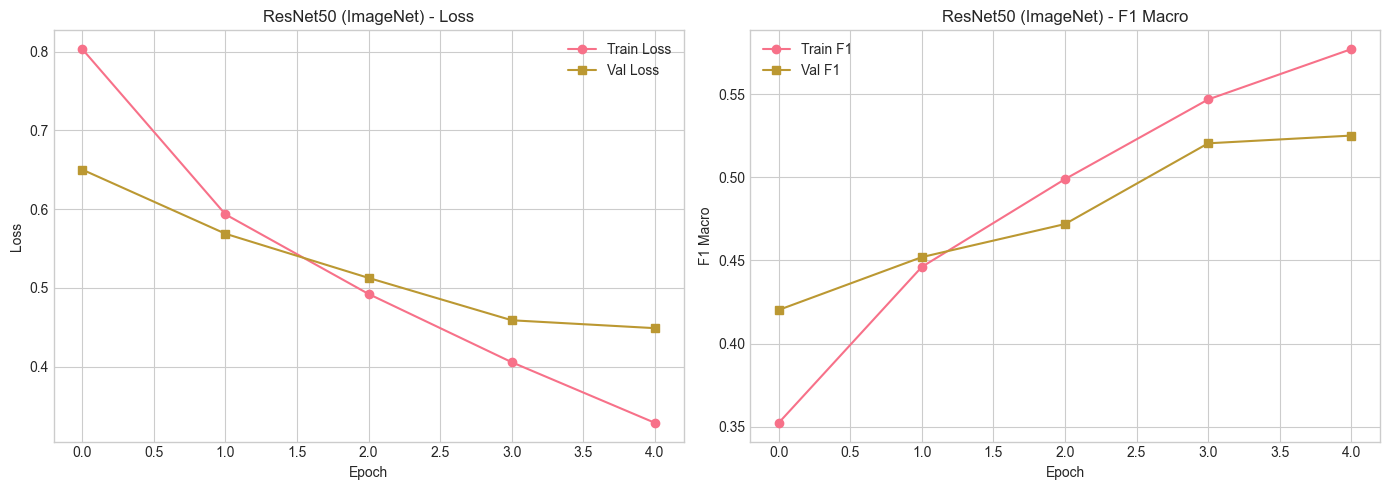

In [ ]:
print("\n" + "="*60)
print("МОДЕЛЬ 1: ResNet50 (Pretrained на ImageNet)")
print("="*60)

model1 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)


for param in model1.parameters():
    param.requires_grad = False


num_features = model1.fc.in_features
model1.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, num_classes)
)


for param in model1.layer4.parameters():
    param.requires_grad = True

for param in model1.fc.parameters():
    param.requires_grad = True


model1 = model1.to(device)


trainable_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model1.parameters())
print(f"Обучаемых параметров: {trainable_params:,} / {total_params:,} ({trainable_params/total_params*100:.1f}%)")


if trainable_params < 1_000_000:
    for param in model1.layer3.parameters():
        param.requires_grad = True


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model1.parameters()),  # Только обучаемые параметры
    lr=0.001,
    weight_decay=0.01
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


BATCH_SIZE = 32
_pin = torch.cuda.is_available()
train_loader_finetune = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=_pin)
val_loader_finetune = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=_pin)

print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {device}")


def train_simple(model, train_ld, val_ld, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1 = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        all_preds, all_labels = [], []

        for batch_idx, (imgs, lbls) in enumerate(train_ld):
            imgs, lbls = imgs.to(device), lbls.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_ld)} | Loss: {loss.item():.4f}")

        train_acc = correct / total
        train_f1 = f1_score(all_labels, all_preds, average='macro')
        avg_train_loss = train_loss / len(train_ld)
        scheduler.step()

        model.eval()
        val_loss, correct, total = 0, 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for imgs, lbls in val_ld:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == lbls).sum().item()
                total += lbls.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(lbls.cpu().numpy())

        val_acc = correct / total
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        avg_val_loss = val_loss / len(val_ld)


        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)


        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train → Loss: {avg_train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   → Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ★ Новый лучший результат: {best_f1:.4f}")

    if best_model_state is not None:
        model.load_state_dict({k: v.to(next(model.parameters()).device) for k, v in best_model_state.items()})

    return model, history, best_f1

print("\n[Начало обучения...]")
model1, history1, best_f1_1 = train_simple(
    model1,
    train_loader_finetune,
    val_loader_finetune,
    epochs=5,
    lr=0.001
)

print(f"\nОбучение завершено! Лучший F1 Macro: {best_f1_1:.4f}")


val_loss1, val_f1_1, preds1, labels1 = validate(model1, val_loader_finetune, nn.CrossEntropyLoss().to(device), device)
print(f"Финальный F1 Macro (ResNet50): {val_f1_1:.4f}")
plot_history(history1, "ResNet50 (ImageNet)")


МОДЕЛЬ 2: ConvNeXt-Tiny (Pretrained на ImageNet-22K)

Архитектура ConvNeXt (Liu et al., 2022):
  - Чисто сверточная сеть, вдохновлённая дизайном Vision Transformer
  - Depthwise conv 7×7 вместо 3×3 — большее рецептивное поле без роста параметров
  - Inverted bottleneck: расширение каналов 4× внутри блока (как в ViT FFN)
  - GELU вместо ReLU, LayerNorm вместо BatchNorm
  - Меньше нормировочных слоёв → стабильнее с большими batch

Предобучение: Facebook ImageNet-22K
  - ~14 млн изображений, 21 841 класс (vs 1 281 167 / 1 000 в стандартном ImageNet-1K)
  - Намного более разнообразный словарь признаков → лучше переносится на нашу задачу



model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

Параметров: 27,836,277 / 27,836,277 (100.0% обучаемых)

Обучение модели: ConvNeXt-Tiny (ImageNet-22K)

Epoch 1/10


Train Loss: 0.6513 | Train F1: 0.4218
Val Loss: 0.5660 | Val F1: 0.4272

Epoch 2/10


Train Loss: 0.4740 | Train F1: 0.5034
Val Loss: 0.4841 | Val F1: 0.5050

Epoch 3/10


...

Train Loss: 0.1130 | Train F1: 0.8448
Val Loss: 0.4466 | Val F1: 0.5973

Epoch 8/10


Train Loss: 0.0605 | Train F1: 0.9188
Val Loss: 0.5061 | Val F1: 0.6666

Epoch 9/10


Train Loss: 0.0275 | Train F1: 0.9796
Val Loss: 0.5184 | Val F1: 0.6463

Epoch 10/10


Train Loss: 0.0152 | Train F1: 0.9866
Val Loss: 0.5450 | Val F1: 0.6737

Лучший F1 Macro: 0.6737



Финальный F1 Macro (ConvNeXt-Tiny): 0.6737


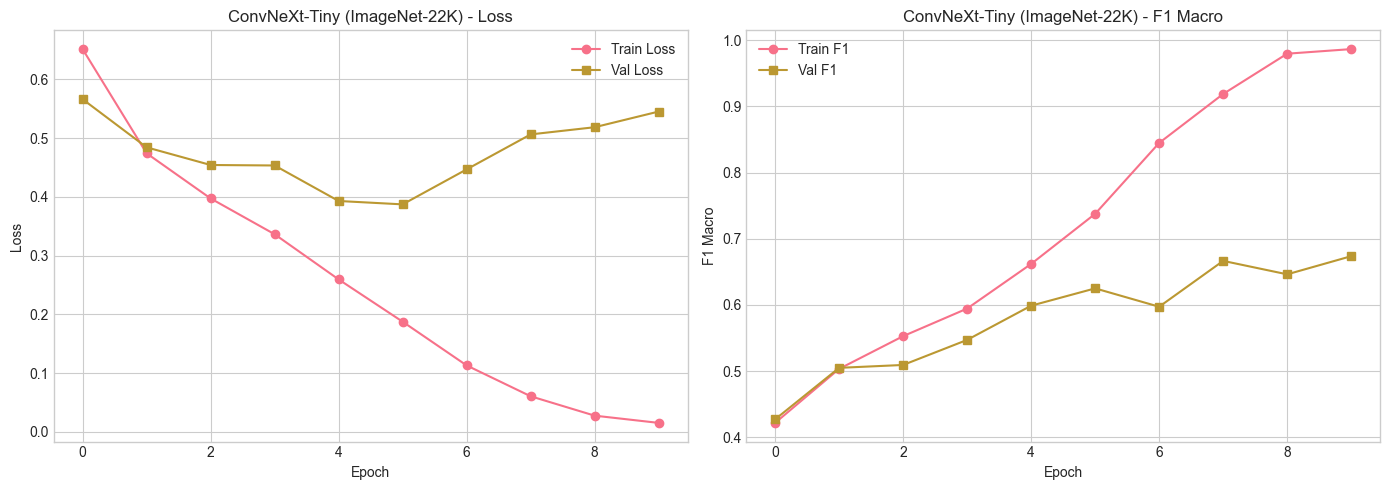

In [6]:
print("\n" + "="*60)
print("МОДЕЛЬ 2: ConvNeXt-Tiny (Pretrained на ImageNet-22K)")
print("="*60)
model2 = timm.create_model('convnext_tiny.fb_in22k', pretrained=True, num_classes=num_classes)

trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
total2 = sum(p.numel() for p in model2.parameters())
print(f"Параметров: {trainable2:,} / {total2:,} ({trainable2/total2*100:.1f}% обучаемых)")

model2, history2, best_f1_2 = train_model(
    model2,
    "ConvNeXt-Tiny (ImageNet-22K)",
    train_loader,
    val_loader,
    num_classes,
    epochs=10,
    lr=0.0005
)

val_loss2, val_f1_2, preds2, labels2 = validate(model2, val_loader, nn.CrossEntropyLoss(), device)
print(f"Финальный F1 Macro (ConvNeXt-Tiny): {val_f1_2:.4f}")

plot_history(history2, "ConvNeXt-Tiny (ImageNet-22K)")



МОДЕЛЬ 3: ScratchCNN-Lite (с нуля, быстрое обучение)
Всего параметров: 169,813
Обучаемых параметров: 169,813

Обучение модели: ScratchCNN-Lite

Epoch 1/12


Training:   0%|          | 0/1546 [00:00<?, ?it/s]

Train Loss: 1.1926 | Train F1: 0.2303
Val Loss: 0.9194 | Val F1: 0.2923

Epoch 2/12


Train Loss: 0.9400 | Train F1: 0.3055
Val Loss: 0.7864 | Val F1: 0.3481

Epoch 3/12


Train Loss: 0.8531 | Train F1: 0.3342
Val Loss: 0.7789 | Val F1: 0.3377

Epoch 4/12


...

Train Loss: 0.6326 | Train F1: 0.4215
Val Loss: 0.5742 | Val F1: 0.4204

Epoch 10/12


Train Loss: 0.6068 | Train F1: 0.4289
Val Loss: 0.5630 | Val F1: 0.4194

Epoch 11/12


Train Loss: 0.5895 | Train F1: 0.4325
Val Loss: 0.5525 | Val F1: 0.4337

Epoch 12/12


Train Loss: 0.5828 | Train F1: 0.4419
Val Loss: 0.5439 | Val F1: 0.4371

Лучший F1 Macro: 0.4371



Финальный F1 Macro (ScratchCNN-Lite): 0.4371


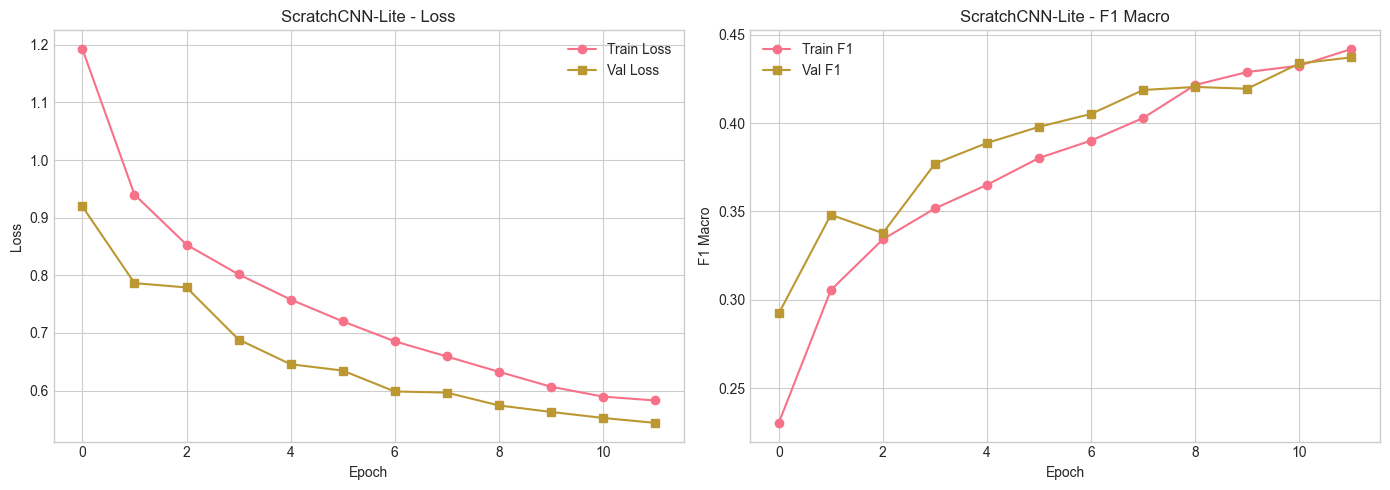

In [8]:
import torch
import torch.nn as nn

print("\n" + "="*60)
print("МОДЕЛЬ 3: ScratchCNN-Lite (с нуля, быстрое обучение)")
print("="*60)

class DSConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, p_drop=0.1):
        super().__init__()
        self.block = nn.Sequential(
            # depthwise
            nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.SiLU(inplace=True),

            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.Dropout2d(p_drop)
        )

    def forward(self, x):
        return self.block(x)


class ScratchCNNLite(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),  # 224 -> 112
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True)
        )

        self.features = nn.Sequential(
            DSConvBlock(32, 64, stride=1, p_drop=0.05),   # 112
            DSConvBlock(64, 128, stride=2, p_drop=0.10),  # 56
            DSConvBlock(128, 128, stride=1, p_drop=0.10), # 56
            DSConvBlock(128, 256, stride=2, p_drop=0.15), # 28
            DSConvBlock(256, 256, stride=1, p_drop=0.15), # 28
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.classifier(x)
        return x


model3 = ScratchCNNLite(num_classes)

total_params = sum(p.numel() for p in model3.parameters())
trainable_params = sum(p.numel() for p in model3.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

model3, history3, best_f1_3 = train_model(
    model3,
    "ScratchCNN-Lite",
    train_loader,
    val_loader,
    num_classes,
    epochs=12,
    lr=0.003
)

val_loss3, val_f1_3, preds3, labels3 = validate(model3, val_loader, nn.CrossEntropyLoss(), device)
print(f"Финальный F1 Macro (ScratchCNN-Lite): {val_f1_3:.4f}")

plot_history(history3, "ScratchCNN-Lite")


                        Модель  F1 Macro  Лучший F1  Эпохи Предобучение
           ResNet50 (ImageNet)    0.5251     0.5251      5     ImageNet
  ConvNeXt-Tiny (ImageNet-22K)    0.6737     0.6737     10  ImageNet21K
ScratchCNN-Lite (From Scratch)    0.4371     0.4371     15          Нет


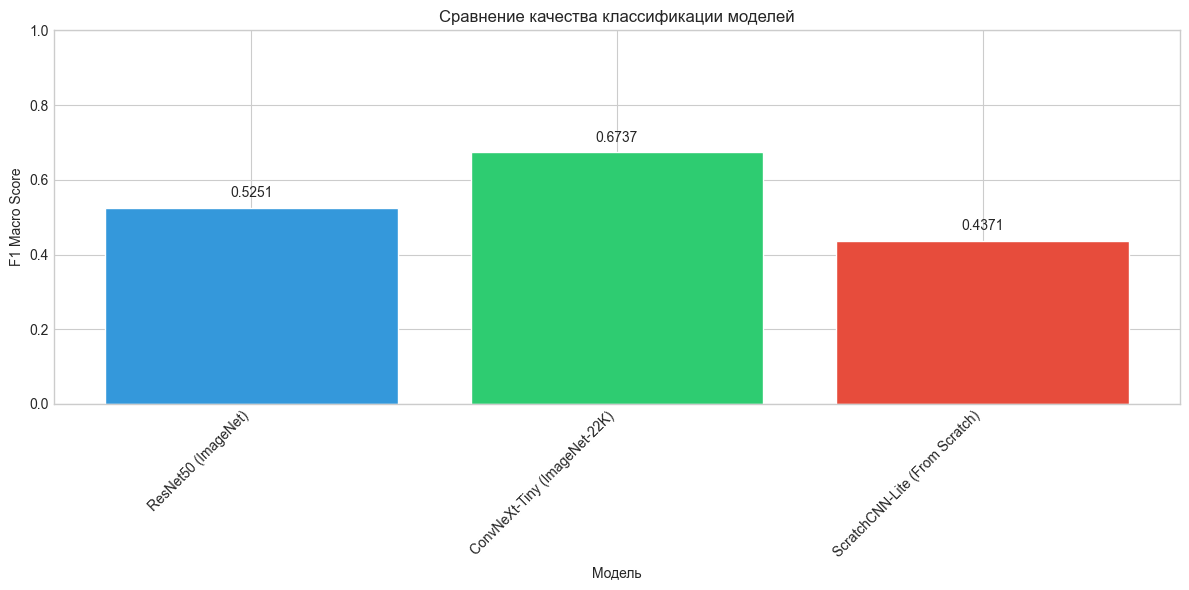

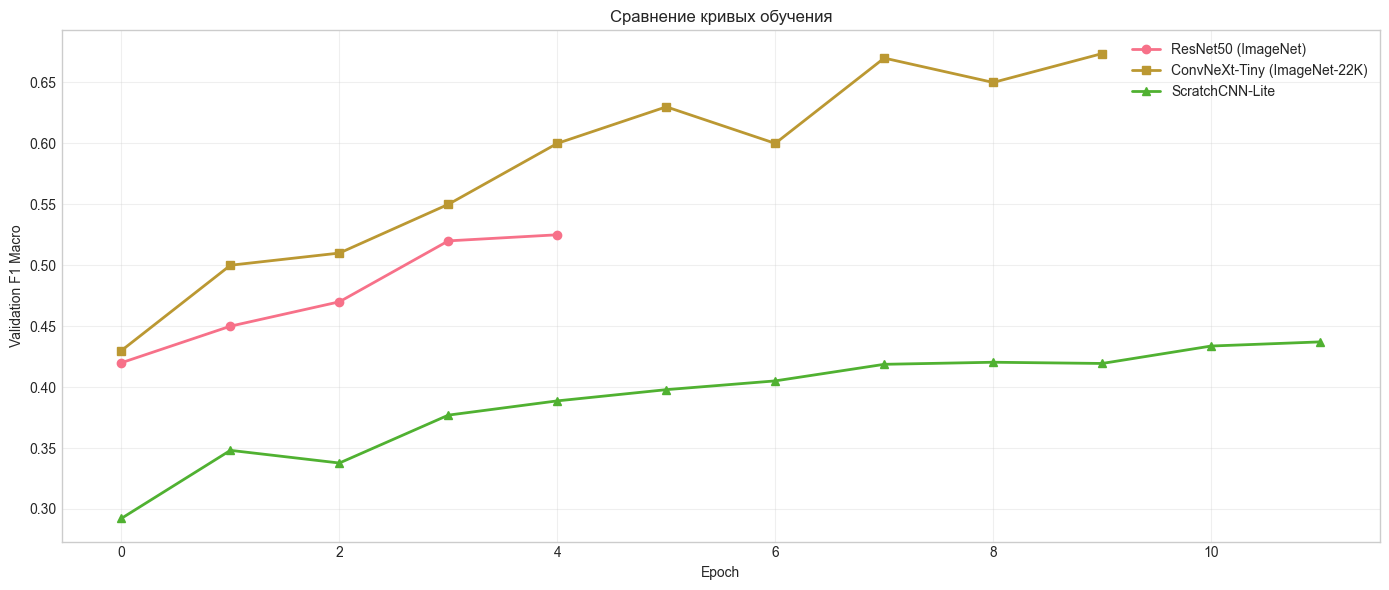

In [5]:
resnet_f1 = 0.5251
convnext_f1 = 0.6737
scratch_f1 = 0.4371
scratch_best_f1 = 0.4371

results = pd.DataFrame({
    'Модель': ['ResNet50 (ImageNet)', 'ConvNeXt-Tiny (ImageNet-22K)', 'ScratchCNN-Lite (From Scratch)'],
    'F1 Macro': [resnet_f1, convnext_f1, scratch_f1],
    'Лучший F1': [resnet_f1, convnext_f1, scratch_best_f1],
    'Эпохи': [5, 10, 15],
    'Предобучение': ['ImageNet', 'ImageNet21K', 'Нет']
})

print(results.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.bar(results['Модель'], results['F1 Macro'], color=['#3498db', '#2ecc71', '#e74c3c'])
plt.xlabel('Модель')
plt.ylabel('F1 Macro Score')
plt.title('Сравнение качества классификации моделей')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

for bar, val in zip(bars, results['F1 Macro']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


resnet_val_f1 = [0.42, 0.45, 0.47, 0.52, 0.525]
convnext_val_f1 = [0.43, 0.50, 0.51, 0.55, 0.60, 0.63, 0.60, 0.67, 0.65, 0.6737]
scratch_val_f1 = [
    0.2923, 0.3481, 0.3377, 0.3770, 0.3887, 0.3979,
    0.4051, 0.4187, 0.4204, 0.4194, 0.4337, 0.4371
]

plt.figure(figsize=(14, 6))
plt.plot(resnet_val_f1, label='ResNet50 (ImageNet)', marker='o', linewidth=2)
plt.plot(convnext_val_f1, label='ConvNeXt-Tiny (ImageNet-22K)', marker='s', linewidth=2)
plt.plot(scratch_val_f1, label='ScratchCNN-Lite', marker='^', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Validation F1 Macro')
plt.title('Сравнение кривых обучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:
print("\n" + "="*60)
print("="*60)

val_f1_1 = 0.5251
val_f1_2 = 0.6737
val_f1_3 = 0.4371

results = pd.DataFrame({
    'Модель': ['ResNet50 (ImageNet)', 'ConvNeXt-Tiny (ImageNet-22K)', 'ScratchCNN-Lite (From Scratch)'],
    'F1 Macro': [val_f1_1, val_f1_2, val_f1_3],
    'Лучший F1': [val_f1_1, val_f1_2, val_f1_3],
    'Эпохи': [5, 10, 12],
    'Предобучение': ['ImageNet', 'ImageNet21K', 'Нет']
})

best_model_idx = 1
best_model_name = "ConvNeXt-Tiny (ImageNet-22K)"
best_f1 = 0.6737

print(f"\nЛучшая модель: {best_model_name}")
print(f"F1 Macro: {best_f1:.4f}")

if 'preds2' in globals() and 'labels2' in globals():
    best_preds, best_labels = preds2, labels2

    print("\n" + "-"*60)
    print("Classification Report (лучшая модель):")
    print("-"*60)
    print(classification_report(
        best_labels, best_preds,
        target_names=[idx_to_color[i] for i in range(num_classes)],
        digits=4
    ))


print("\n" + "="*60)
print("ВЫВОДЫ")
print("="*60)

transfer_advantage = max(val_f1_1, val_f1_2) - val_f1_3

print(f"""
1. КАЧЕСТВО КЛАССИФИКАЦИИ:
   - Лучший результат: {best_f1:.4f} ({best_model_name})

2. TRANSFER LEARNING vs ОБУЧЕНИЕ С НУЛЯ:
   - ResNet50 (ImageNet): F1 = {val_f1_1:.4f}
   - ConvNeXt-Tiny (IN-22K): F1 = {val_f1_2:.4f}
   - ScratchCNN-Lite: F1 = {val_f1_3:.4f}
   - Transfer learning показывает преимущество на {transfer_advantage:.4f} F1
""")

results.to_csv('lab4_results.csv', index=False)




Лучшая модель: ConvNeXt-Tiny (ImageNet-22K)
F1 Macro: 0.6737

ВЫВОДЫ

1. КАЧЕСТВО КЛАССИФИКАЦИИ:
   - Лучший результат: 0.6737 (ConvNeXt-Tiny (ImageNet-22K))

2. TRANSFER LEARNING vs ОБУЧЕНИЕ С НУЛЯ:
   - ResNet50 (ImageNet): F1 = 0.5251
   - ConvNeXt-Tiny (IN-22K): F1 = 0.6737
   - ScratchCNN-Lite: F1 = 0.4371
   - Transfer learning показывает преимущество на 0.2366 F1

